In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports and configuration**

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, ConfusionMatrixDisplay
)
from torchvision.transforms import (
    CenterCrop, RandomResizedCrop,
    ColorJitter, Compose, Normalize,
    RandomHorizontalFlip, Resize, ToTensor
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    AutoImageProcessor, AutoModelForImageClassification,
    get_cosine_schedule_with_warmup
)

In [5]:
MODEL_ID = "microsoft/swin-tiny-patch4-window7-224"
OUTPUT_DIR = "/content/drive/MyDrive/Fine tuned models/vit_beans_best"
IMAGE_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
print("Device: ", device)

Device:  cuda


**Dataset and pretrained model load**

In [7]:
dataset = load_dataset("AI-Lab-Makerere/beans")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


In [9]:
label_names = dataset["train"].features["labels"].names

id2label = {
    class_id: label for class_id, label in enumerate(label_names)
}

label2id = {
    label: class_id for class_id, label in enumerate(label_names)
}

print("Classes: ", label_names)

Classes:  ['angular_leaf_spot', 'bean_rust', 'healthy']


In [10]:
image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageClassification.from_pretrained(
    MODEL_ID
).to(device)

model.eval()

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (attention): SwinAttention(
                (q_proj): Linear(in_features=96, out_features=96, bias=True)
                (k_proj): Linear(in_features=96, out_features=96, bias=True)
                (v_proj): Linear(in_features=96, out_features=96, bias=True)
                (o_proj): Linear(in_features=96, out_features=96, bias=True)
                (relative_position_bias): SwinRelativePositionBias()
              )
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
         

**Pretrained inference using real bean image** 

In [12]:
sample =dataset["validation"][0]
image = sample["image"].convert("RGB")
true_label = id2label[sample["labels"]]

inputs = image_processor(
    images=image,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.inference_mode():
    outputs = model(
        pixel_values=pixel_values
    )
probabilities = torch.softmax(outputs.logits, dim=-1)[0]

top_scores, top_indices = torch.topk(
    probabilities, k=3
)

Original image size: (500, 500)
Model input shape   : torch.Size([1, 3, 224, 224])
Logits shape        : torch.Size([1, 1000])
Bean ground truth   : angular_leaf_spot


Pretrained ImageNet predictions:
ant, emmet, pismire 0.15
leaf beetle, chrysomelid 0.15
pot, flowerpot 0.06


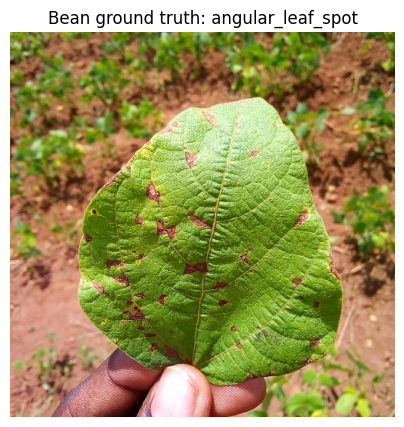

In [15]:
print("Original image size:", image.size)
print("Model input shape   :", pixel_values.shape)
print("Logits shape        :", outputs.logits.shape)
print("Bean ground truth   :", true_label)
print("\n\nPretrained ImageNet predictions:")

for class_id, score in zip(
    top_indices.tolist(), top_scores.tolist()
):
    print(
        f"{model.config.id2label[class_id]}"
        f" {score:.2f}"
    )

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"Bean ground truth: {true_label}")
plt.axis("off")
plt.show()

**Training and evaluation transforms**

In [16]:
normalize = Normalize(
    mean=image_processor.image_mean,
    std=image_processor.image_std
)

train_transform = Compose([
    RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    RandomHorizontalFlip(p=0.5),
    ColorJitter(
        brightness=0.15, contrast=0.15, saturation=0.10
    ),
    ToTensor(),
    normalize,
])

evaluation_transform = Compose([
    Resize(256),
    CenterCrop(IMAGE_SIZE),
    ToTensor(),
    normalize
])

def apply_train_transform(examples):
    examples["pixel_values"] = [
        train_transform(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

def apply_evaluation_transform(examples):
    examples["pixel_values"] = [
        evaluation_transform(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

In [18]:
train_dataset = dataset["train"].with_transform(apply_train_transform)

test_dataset = dataset["test"].with_transform(
    apply_evaluation_transform
)

evaluation_dataset = dataset["validation"].with_transform(
    apply_evaluation_transform
)

**DataLoaders**

In [19]:
BATCH_SIZE = 16
def collate_fn(batch):
    pixel_values = torch.stack([
        item["pixel_values"] for item in batch
    ])
    labels = torch.tensor([
        item["labels"] for item in batch
    ], dtype=torch.long)
    
    return {
        "pixel_values": pixel_values,
        "labels": labels,
    }

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

validation_loader = DataLoader(
    dataset=evaluation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

batch = next(iter(train_loader))
print("Images: ", batch["pixel_values"].shape)
print("Labels: ", batch["labels"].shape)
print("First labels:", batch["labels"][:10])

Images:  torch.Size([16, 3, 224, 224])
Labels:  torch.Size([16])
First labels: tensor([1, 1, 0, 1, 0, 2, 1, 0, 1, 1])
